# Feature selection analysis

## Introduction & Theoretical Justification

Feature selection is a critical step in preprocessing high-dimensional datasets for machine learning. By reducing dimensionality, we can lower computational costs and prevent the model from learning noise. As noted by Shayestegan et al. (2024), "Feature selection not only identifies the essential features and improves the quality of the dataset but also eliminates undesirable features that impair the dataset's quality."

To ensure our dataset contains only informative and non-redundant variables, we applied two standard filter-based techniques:

### 1. Variance Thresholding

Our first filter evaluates the internal variance of each individual feature. According to Kamalov et al. (2025), "Variance threshold is a filter approach that discards features whose variances are below a chosen cutoff. It relies on the intuition that features with little or no variance are unlikely to offer much predictive power."

Because our dataset includes features with extreme outliers (such as EDA and BVP) alongside bounded survey data, evaluating raw variance is misleading. Therefore, we applied our model's exact preprocessing pipeline (RobustScaler for physiological/EEG data and MinMaxScaler for survey data) before calculating the variance. This ensures the variance reflects the exact data distribution the model will process.

### 2. Correlation Analysis

Our second filter examines the relationships between different features. Highly correlated features provide redundant information to the model. Alqaraleh et al. (2025) demonstrate that employing Correlation-based Feature Selection (CFS) helps "identify a subset of informative [features], thereby decreasing data dimensions and isolating discriminative features," which generally leads to higher classification accuracy on filtered datasets.

For this section, we calculated the absolute correlation matrix for all features and plotted the distribution of these correlations in a histogram to identify any highly redundant pairs


### Loading the dataset

The code for this process is hidden by default, as it is the same process done by model_exploration


In [15]:
import pandas as pd
import sys

# load data set
df = pd.read_csv("../NPFC-Test_Database_V2.csv")

relevant_columns = [
    "Subject_ID",
    "Timestamp",
    "Test_Time",
    "Task_Num",
    "Task_Time",
    "Task_Type",
    "Frame",
    "Task_Frame",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Face_Detection",
    "resmasknet_anger",
    "resmasknet_disgust",
    "resmasknet_fear",
    "resmasknet_happiness",
    "resmasknet_sadness",
    "resmasknet_surprise",
    "resmasknet_neutral",
    "Temperature",
    "EDA",
    "BVP",
    "HeadBandOn",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

df = df[relevant_columns]

In [16]:
sys.path.append("./data-preprocessing")
from data_preparation import (
    prepare_data,
    normalize_signals_with_mediation_baseline,
    align_lag_signals,
)

# Clean, normalize and align data based on exploratory data analysis and domain knowledge
df = normalize_signals_with_mediation_baseline(df)
df = align_lag_signals(df)
df = prepare_data(df)

In [17]:
# Grab resmasknet_dominant_emotion if you also want the emotion
result_df_regression = df["resmasknet_max_emotion_value"]

# Select relevant features
feature_columns = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature",
    "EDA",
    "BVP",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]

# Output the results of the feature selection
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22177 entries, 14 to 47904
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Selfreport_valence   22177 non-null  int64  
 1   Selfreport_arousal   22177 non-null  int64  
 2   Selfreport_focus     22177 non-null  int64  
 3   Temperature          21902 non-null  float64
 4   EDA                  21902 non-null  float64
 5   BVP                  21902 non-null  float64
 6   Delta_TP9            22177 non-null  float64
 7   Delta_AF7            22177 non-null  float64
 8   Delta_AF8            22177 non-null  float64
 9   Delta_TP10           22177 non-null  float64
 10  Theta_TP9            22177 non-null  float64
 11  Theta_AF7            22177 non-null  float64
 12  Theta_AF8            22177 non-null  float64
 13  Theta_TP10           22177 non-null  float64
 14  Alpha_TP9            22177 non-null  float64
 15  Alpha_AF7            22177 non-null  flo

# Correlation analysis

Here we analyze if a pair of 2 features have a high correlation between them.

If 2 features have a very high correlation it would mean that one feature can be highly predicted by the other. Therefore, if we included both features that were very highly correlated, it would not add a lot of information to the model.

First we do the correlation matrix and then we graph the correlations in a histogram.


In [ ]:
import numpy as np

corr_matrix = feature_df.corr().abs()

# Select the upper triangle of the correlation matrix onlly
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.90
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

df_filtered = df.drop(columns=to_drop)

# --- Output Results ---
print("--- Absolute Correlation Matrix ---")
print(corr_matrix)
print("\n--- Upper Triangle (Isolated Pairs) ---")
print(upper_tri)
print(f"\nFeatures identified for removal (threshold > {threshold}): {to_drop}")
print(f"\nRemaining features shape: {df_filtered.shape}")

--- Absolute Correlation Matrix ---
                     Selfreport_valence  Selfreport_arousal  Selfreport_focus  \
Selfreport_valence             1.000000            0.660106          0.669002   
Selfreport_arousal             0.660106            1.000000          0.634366   
Selfreport_focus               0.669002            0.634366          1.000000   
Temperature                    0.041757            0.038989          0.055735   
EDA                            0.163180            0.162500          0.168737   
BVP                            0.003907            0.003716          0.001036   
Delta_TP9                      0.006701            0.022034          0.012267   
Delta_AF7                      0.073558            0.049499          0.011366   
Delta_AF8                      0.010425            0.024243          0.016148   
Delta_TP10                     0.019066            0.021134          0.029661   
Theta_TP9                      0.028891            0.008454          0.01

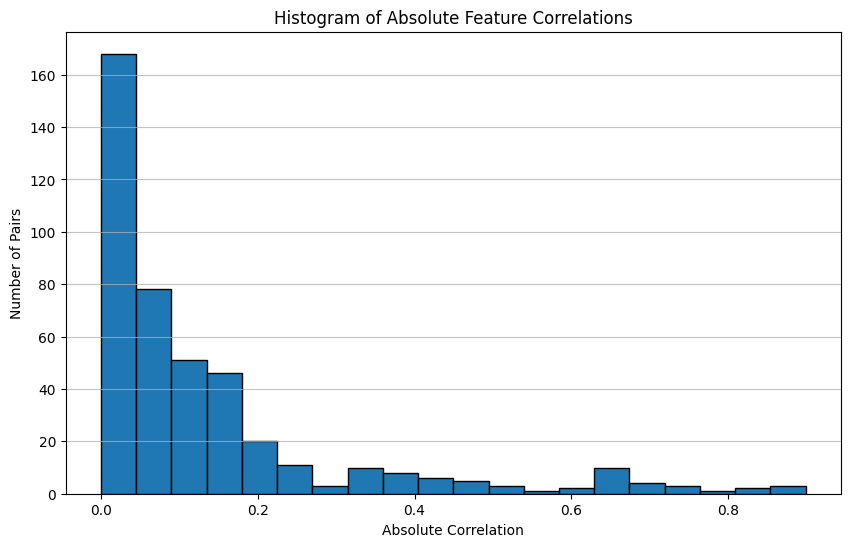

In [ ]:
import matplotlib.pyplot as plt

# Extract all valid (non-NaN) correlation values from the upper triangle
corr_values = upper_tri.values.flatten()
corr_values = corr_values[~np.isnan(corr_values)]

plt.figure(figsize=(10, 6))
plt.hist(corr_values, bins=20, edgecolor="black")
plt.title("Histogram of Absolute Feature Correlations")
plt.xlabel("Absolute Correlation")
plt.ylabel("Number of Pairs")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [ ]:
corr_threshold = 0.60

corr_pairs = upper_tri.stack().reset_index()
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr_pairs = corr_pairs[corr_pairs["Correlation"] > corr_threshold].sort_values(
    by="Correlation", ascending=False
)
high_corr_pairs = high_corr_pairs.reset_index(drop=True)

print(f"Feature pairs with an absolute correlation higher than {corr_threshold}:")
display(high_corr_pairs)

Feature pairs with an absolute correlation higher than 0.6:


,Feature 1,Feature 2,Correlation
0,Theta_AF7,Alpha_AF7,0.898716
1,Delta_AF7,Theta_AF7,0.883060
2,Beta_AF7,Gamma_AF7,0.882102
3,Beta_AF8,Gamma_AF8,0.846490
4,Delta_AF7,Alpha_AF7,0.833525
5,Alpha_AF7,Beta_AF7,0.770017
6,Theta_AF8,Alpha_AF8,0.737013
7,Gamma_TP9,Gamma_TP10,0.725018
8,Delta_AF8,Theta_AF8,0.721164
9,Delta_TP9,Theta_TP9,0.710931


### Correlation analysis result

The histogram of absolute feature correlations demonstrates that the vast majority of feature pairs share very little linear relationship (correlations below 0.2). While a few specific pairs exhibit moderate correlation — such as spatially adjacent brainwave frequencies (expected due to biological proximity) and the Selfreport_valence and Selfreport_focus pair (0.669) — none of these approach the strict redundancy threshold (e.g., > 0.90) required to justify removal. These correlated pairs still capture distinct, nuanced elements of the physiological and psychological data.


# Variance Thresholding Analysis

As supported by Solovko (2026), setting a variance threshold of 0.05 is an established empirical baseline for near-zero variance filtering, effectively isolating "non-contributory features" without prematurely discarding valuable, low-amplitude physiological signals.


--- Robust/MinMax Scaled Variances (Lowest 10) ---
Perceived_Tiredness    0.063040
Perceived_Stress       0.070233
Selfreport_valence     0.095217
Selfreport_arousal     0.103820
Selfreport_focus       0.104406
Delta_AF8              0.406119
Gamma_AF8              0.495637
Temperature            0.495672
Alpha_TP9              0.547596
Delta_TP9              0.557662
dtype: float64

Features below threshold (0.05): 0


/var/folders/fc/qc4r12r91f31jlcsr_z4lzvc0000gn/T/ipykernel_16858/3475165253.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df.drop(binary_features, axis=1, inplace=True)


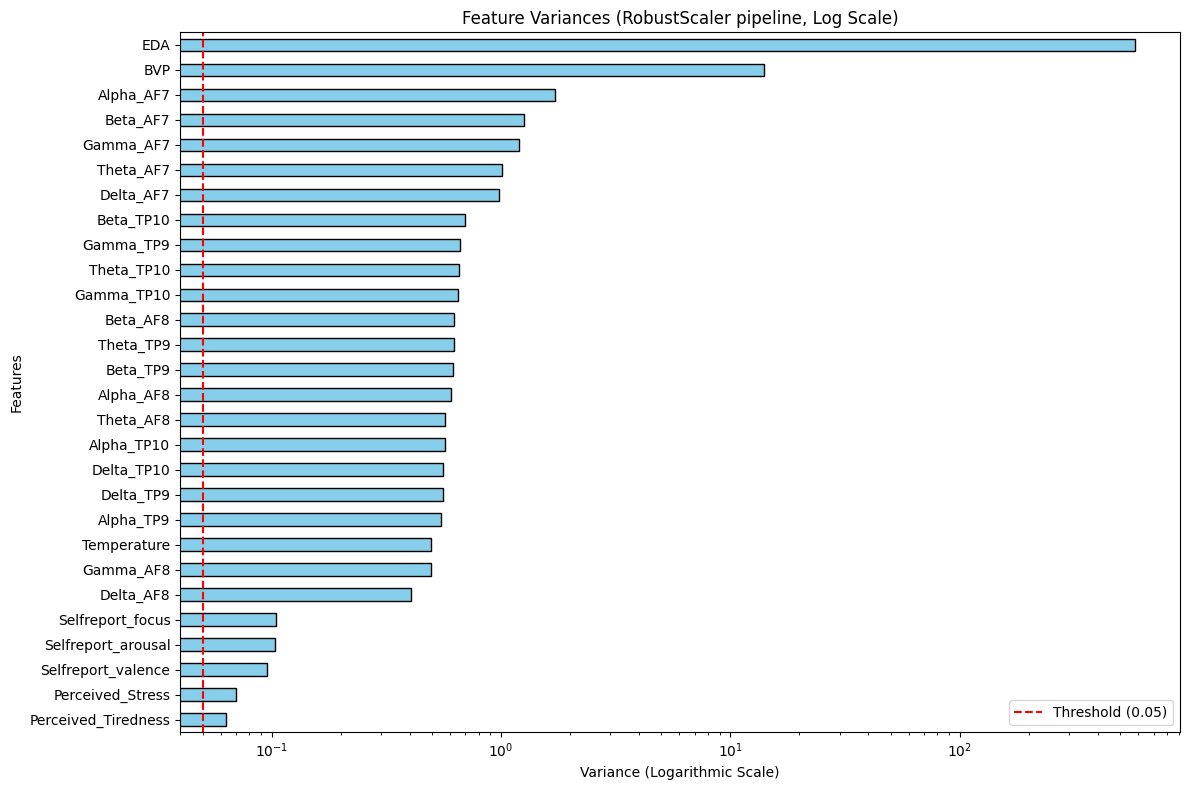

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

sensor_and_eeg_features = [
    "Temperature",
    "EDA",
    "BVP",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

survey_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
]

binary_features = ["Gender", "Wearing_Glasses"]

# Ignore survey data, since low variance would be due to population imbalance from the dataset
feature_df.drop(binary_features, axis=1, inplace=True)

# Scale the data using the same preprocessor as training
preprocessor = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("minmax_survey", MinMaxScaler(), survey_features),
    ]
)

scaled_data = preprocessor.fit_transform(feature_df)
transformed_columns = sensor_and_eeg_features + survey_features
scaled_df = pd.DataFrame(scaled_data, columns=transformed_columns)

continuous_scaled_df = scaled_df
scaled_variances = continuous_scaled_df.var().sort_values(ascending=True)

var_threshold = 0.05
low_variance_features = scaled_variances[scaled_variances < var_threshold]

print("--- Robust/MinMax Scaled Variances (Lowest 10) ---")
print(scaled_variances.head(10))
print(f"\nFeatures below threshold ({var_threshold}): {len(low_variance_features)}")

# (Outliers in EDA/BVP will cause massive variance spikes, log scale keeps it readable)
plt.figure(figsize=(12, 8))
scaled_variances.plot(kind="barh", color="skyblue", edgecolor="black", logx=True)
plt.axvline(
    x=var_threshold, color="red", linestyle="--", label=f"Threshold ({var_threshold})"
)
plt.title("Feature Variances (RobustScaler pipeline, Log Scale)")
plt.xlabel("Variance (Logarithmic Scale)")
plt.ylabel("Features")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
feature_df["EDA"].describe()

count    21902.000000
mean         0.123315
std          1.138302
min         -3.633824
25%         -0.009814
50%          0.004256
75%          0.037505
max         13.278332
Name: EDA, dtype: float64

### Variance Analysis Results

As visualized in the logarithmic variance chart, after proper robust scaling, all features exhibited a variance well above the baseline threshold of 0.05. The logarithmic scale highlights that even features heavily skewed by outliers (EDA and BVP) maintain significant dynamic variance within their core distributions. Because no feature approaches a near-zero variance, we can conclude that every feature actively captures fluctuations in the participants' states and environments. No features act as constants.


# Feature Selection Conclusions

Based on the quantitative results from both the variance thresholding and correlation analysis, there is no statistical justification for dropping any features. Every variable demonstrates sufficient independent variance and low redundancy. Therefore, the complete feature set will be retained for model training.


# References

- Alqaraleh, M., Salem Alzboon, M., Subhi Al-Batah, M., & Solayman Migdadi, H. (2025). From complexity to clarity: Improving microarray classification with correlation-based feature selection. LatIA, 3, 84. https://doi.org/10.62486/latia202584
- Kamalov, F., Sulieman, H., Alzaatreh, A., Emarly, M., Chamlal, H., & Safaraliev, M. (2025). Mathematical methods in feature selection: A review. Mathematics, 13(6). https://doi.org/10.3390/math13060996
- Shayestegan, M., Kohout, J., Verešpejová, L., Chovanec, M., & Mareš, J. (2024). Comparison of feature selection and supervised methods for classifying gait disorders. IEEE Access, 12, 17876–17894. https://doi.org/10.1109/access.2024.3360861
- Solovko, Y. (2026, February 18). ML-driven detection and reduction of ballast information in multi-modal datasets. arXiv.org. https://arxiv.org/abs/2602.16876
